<a href="https://colab.research.google.com/github/pranavvup-byte/ml-pratical-week/blob/main/week_3_pratical_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.listdir('/content/drive/MyDrive/collab'))

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/collab/placement_predict_50k.csv')

print(df.head())
print(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['placement_predict_50k.csv', 'skill exp1', 'ml pra exp-1', 'pratical ml exp 2.ipynb']
   StudentID  Gender       City CollegeTier      Stream Specialisation Hostel  \
0          1  Female      Delhi       Tier3          IT    DataScience    Yes   
1          2    Male    Chennai       Tier2         ECE             AI    Yes   
2          3  Female  Hyderabad       Tier3         ECE     Networking     No   
3          4  Female     Jaipur       Tier3         ECE       Embedded     No   
4          5    Male  Ahmedabad       Tier3  Mechanical    DataScience     No   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Certifications  Publications  \
0               Yes       6.39       6.84  ...               1             0   
1                No       5.95       6.74  ...               2             0   
2                No       7.13       8.11  ...           

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

file_path = "/content/drive/MyDrive/collab/placement_predict_50k.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
print(df.columns.tolist())

target_col = "CGPA"

drop_cols = [col for col in ["CGPA", "StudentID", "CGPA_Tier"] if col in df.columns]

feature_df = df.drop(columns=drop_cols).select_dtypes(include=[np.number])
feature_df = feature_df.fillna(feature_df.median())

X = feature_df.values
y = df[target_col].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

def gradient_descent(X, y, learning_rate=0.01, iterations=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    for i in range(iterations):
        predictions = X @ theta
        error = predictions - y
        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)
        gradient = (1 / m) * (X.T @ error)
        theta = theta - learning_rate * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss = {loss:.4f}")

    return theta, losses

theta, losses = gradient_descent(
    X_train_b,
    y_train,
    learning_rate=0.01,
    iterations=1000
)

y_pred = X_test_b @ theta

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nGradient Descent Results")
print("Weights (Theta):")
print(theta.flatten())

print("Mean Squared Error:", round(mse, 4))
print("Root Mean Squared Error:", round(rmse, 4))
print("R² Score:", round(r2, 4))

lr = LinearRegression()
lr.fit(X_train, y_train)

sk_pred = lr.predict(X_test)

print("\nScikit-Learn Linear Regression")
print("R² Score:", round(r2_score(y_test, sk_pred), 4))
print("Mean Squared Error:", round(mean_squared_error(y_test, sk_pred), 4))

comparison = pd.DataFrame({
    "Actual CGPA": y_test.flatten(),
    "Predicted CGPA": y_pred.flatten()
})

print("\nSample Predictions:")
print(comparison.head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Loaded Successfully!
Shape: (50000, 21)
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly']
Iteration    0 | Loss = 27.1394
Iteration  100 | Loss = 3.5957
Iteration  200 | Loss = 0.5039
Iteration  300 | Loss = 0.0894
Iteration  400 | Loss = 0.0338
Iteration  500 | Loss = 0.0263
Iteration  600 | Loss = 0.0252
Iteration  700 | Loss = 0.0251
Iteration  800 | Loss = 0.0250
Iteration  900 | Loss = 0.0250

Gradient Descent Results
Weights (Theta):
[ 7.29885264e+00  1.51572915e-01  6.19255015e-02  9.18994042e-02
  6.11528698e-02  9.21034270e-02  3.59116610e-02  1.42812012e-01
  1.535860

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Iteration    0 | Loss: 27.1394
Iteration  100 | Loss: 3.5957
Iteration  200 | Loss: 0.5039
Iteration  300 | Loss: 0.0894
Iteration  400 | Loss: 0.0338
Iteration  500 | Loss: 0.0263
Iteration  600 | Loss: 0.0252
Iteration  700 | Loss: 0.0251
Iteration  800 | Loss: 0.0250
Iteration  900 | Loss: 0.0250

Gradient Descent Results
Weights (Theta):
[ 7.29885264e+00  1.51572915e-01  6.19255015e-02  9.18994042e-02
  6.11528698e-02  9.21034270e-02  3.59116610e-02  1.42812012e-01
  1.53586067e-01  1.62139076e-01  1.37183398e-01  2.54455045e-02
 -3.15083847e-04]
Mean Squared Error: 0.0502
Root Mean Squared Error: 0.2240
R² Score: 0.9508

Scikit-Learn Linear Regression
R² Score: 0.9508
Mean Squared Error: 0.0502

Sample Predictions:
   Actual CGPA  Predicted CGPA
0         6.70        6.985290
1         7.41        7.220702
2         7.58        7.427995
3         6.85   

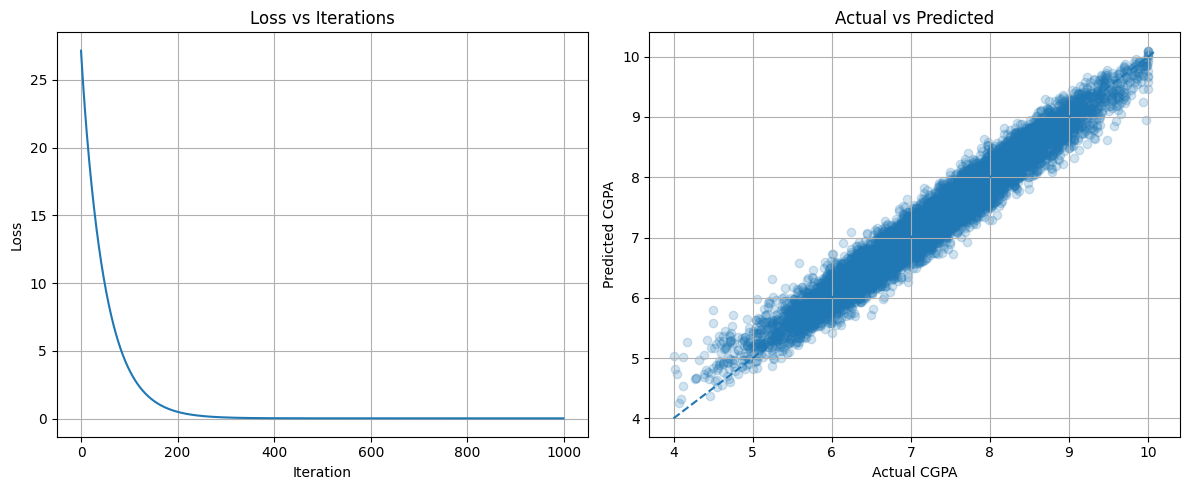

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

file_path = "/content/drive/MyDrive/collab/placement_predict_50k_adjusted.csv"

df = pd.read_csv(file_path)

target_col = "CGPA"

sgpa_cols = [f"SGPA_Sem{i}" for i in range(1, 9)]
drop_cols = [c for c in [target_col, "StudentID", "CGPA_Tier"] + sgpa_cols if c in df.columns]

feature_df = df.drop(columns=drop_cols).select_dtypes(include=[np.number])
feature_df = feature_df.fillna(feature_df.median())

X = feature_df.values
y = df[target_col].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

def gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    for i in range(n_iters):
        y_pred = X @ theta
        error = y_pred - y

        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)

        gradient = (1 / m) * (X.T @ error)

        theta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss: {loss:.4f}")

    return theta, losses

theta, losses = gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_iters=1000
)

y_pred = X_test_b @ theta

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nGradient Descent Results")
print("Weights (Theta):")
print(theta.ravel())
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

print("\nScikit-Learn Linear Regression")
print(f"R² Score: {r2_score(y_test, sk_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, sk_pred):.4f}")

comparison = pd.DataFrame({
    "Actual CGPA": y_test.flatten(),
    "Predicted CGPA": y_pred.flatten()
})

print("\nSample Predictions:")
print(comparison.head(10))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(range(len(losses)), losses)
axes[0].set_title("Loss vs Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].scatter(y_test, y_pred, alpha=0.2)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[1].plot(lims, lims, "--")
axes[1].set_title("Actual vs Predicted")
axes[1].set_xlabel("Actual CGPA")
axes[1].set_ylabel("Predicted CGPA")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("gradient_descent_plots.png", dpi=150)
plt.show()